# Modules

In [1]:
import json
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import interp1d

from longitudinal_arm_swing.constants import *

# Constants

In [10]:
filter_type = 'filtered_gait'
segment_length = '0_20'
population = 'pd'
measures = ['median', '95p', 'median_cov']

path_l1tf = os.path.join(BASE_PATH, 'measures', filter_type, segment_length)

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
snr_lambda_filename = f'{population}_snr_matrix_95p.csv'

min_vals = {
    'median': 2,
    '95p': 5
}

baseline_week = 2
final_week = 104
final_week_range = np.arange(baseline_week + 2, final_week + 1, 2)

# Functions

In [ ]:
def interpolate_limited(row, max_interp_gap=np.inf, max_extrap_gap=2,
                        block_forward_extrap_from=None, block_backward_extrap_to=None):
    x = np.arange(len(row))
    y = row.values
    valid = ~np.isnan(y)
    
    if valid.sum() < 2:
        return row.copy()
    
    f = interp1d(x[valid], y[valid], kind='linear', fill_value='extrapolate')
    y_filled = f(x)

    # Determine extrapolation limits
    first_valid = np.min(np.where(valid)[0])
    last_valid = np.max(np.where(valid)[0])

    # Build mask for missing values
    mask = np.isnan(y)

    # Interpolation: missing values between first and last valid index
    interp_mask = (x > first_valid) & (x < last_valid) & mask
    interp_distance = np.zeros_like(y, dtype=float)

    for i in np.where(interp_mask)[0]:
        prev_valid = valid[:i].nonzero()[0]
        next_valid = valid[i+1:].nonzero()[0] + i + 1
        if len(prev_valid) > 0 and len(next_valid) > 0:
            gap = next_valid[0] - prev_valid[-1]
            if gap <= max_interp_gap:
                interp_distance[i] = gap
            else:
                interp_mask[i] = False
        else:
            interp_mask[i] = False

    # Extrapolation: before first or after last valid index
    extrap_mask = ((x < first_valid) | (x > last_valid)) & mask
    distance = np.abs(np.expand_dims(x, 1) - np.where(valid)[0])
    min_dist_to_valid = distance.min(axis=1)
    extrap_mask &= (min_dist_to_valid <= max_extrap_gap)

    # Combine allowed fill positions
    final_mask = interp_mask | extrap_mask

    # Apply optional blocking
    if block_forward_extrap_from is not None:
        final_mask[block_forward_extrap_from:] = False
    if block_backward_extrap_to is not None:
        final_mask[:block_backward_extrap_to] = False

    result = row.copy()
    result[final_mask] = y_filled[final_mask]
    return result


# Load

In [ ]:
l1tf_values = {
    'pd': {
        'measure': {},
        'signal': {},
        'signal_interp': {},
        'error': {},
        'snr_lambda': {},
    },
    'controls': {
        'measure': {},
        'signal': {},
        'signal_interp': {},
        'error': {},
    }
}
l1tf_phased = {}

for measure in measures:
    measure_extended = f'{measure}_range_of_motion'

    df_pd_med_measure = pd.read_csv(os.path.join(path_l1tf, f'pd_med_measure_{measure_extended}.csv'))
    df_pd_no_med_measure = pd.read_csv(os.path.join(path_l1tf, f'pd_no_med_measure_{measure_extended}.csv'))
    l1tf_values['pd']['measure'][measure] = pd.concat([df_pd_med_measure, df_pd_no_med_measure], axis=0).reset_index(drop=True)

    original_cols = l1tf_values['pd']['measure'][measure].columns
    l1tf_values['pd']['measure'][measure].columns = [f'week{col}' for col in original_cols]

    l1tf_values['pd']['signal'][measure] = pd.read_csv(os.path.join(path_l1tf, f'pd_signal_{measure_extended}.csv'))
    l1tf_values['pd']['error'][measure] = pd.read_csv(os.path.join(path_l1tf, f'pd_lambda_error_weighted_{measure_extended}.csv'), header=None)

    l1tf_values['pd']['snr_lambda'][measure] = pd.read_csv(os.path.join(path_l1tf, f'pd_snr_matrix_{measure_extended}.csv'))

    l1tf_values['controls']['measure'][measure] = pd.read_csv(os.path.join(path_l1tf, f'controls_measure_{measure_extended}.csv'))

    original_cols = l1tf_values['controls']['measure'][measure].columns
    l1tf_values['controls']['measure'][measure].columns = [f'week{col}' for col in original_cols]

    l1tf_values['controls']['signal'][measure] = pd.read_csv(os.path.join(path_l1tf, f'controls_signal_{measure_extended}.csv'))
    l1tf_values['controls']['error'][measure] = pd.read_csv(os.path.join(path_l1tf, f'controls_lambda_error_weighted_{measure_extended}.csv'), header=None)

    l1tf_phased[measure] = {}
    for week in final_week_range:
        l1tf_phased[measure][week] = pd.read_csv(os.path.join(path_l1tf, 'lambda_fit_by_duration', f'pd_signal_{measure_extended}_upto_{week}w.csv'))

with open(os.path.join(path_l1tf, pd_med_id_filename), 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(os.path.join(path_l1tf, pd_no_med_id_filename), 'r') as f:
    pd_no_med_ids = f.read().splitlines()

with open(os.path.join(PATH_IDS, 'affected_side_ids.json'), 'r') as f:
    affected_side_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'med_info_ids.json'), 'r') as f:
    med_info_ids = json.load(f)

start_med_week_dict = {
    'ppp': pd.read_csv(os.path.join(PATH_CLINICAL_DATA, 'ppp', PPP_START_MED_FILENAME)),
    'denovo': pd.read_csv(os.path.join(PATH_CLINICAL_DATA, 'denovo', DENOVO_START_MED_WEEK_FILENAME))
}

df_measures_inclusion = pd.read_parquet(os.path.join(BASE_PATH, 'measures', 'digital_measures.parquet'))

# Data preparation

In [ ]:
ids_start_med = med_info_ids['groups']['start_med']['ppp'] + med_info_ids['groups']['start_med']['denovo']
idx_pre_start_med = [len(pd_med_ids) + pd_no_med_ids.index(i) for i in ids_start_med if i in pd_no_med_ids]
idx_post_start_med = [pd_med_ids.index(i) for i in ids_start_med if i in pd_med_ids]

In [ ]:
# Extrapolate the signal for a maximum of 4 weeks at the edges 
# - Note: for IDs starting medication, not forward extrapolation pre-med or backward extrapolation post-med

# Interpolate the signal for a maximimum of 4 weeks from any point of two separated datapoints
signal_ids = pd_med_ids + pd_no_med_ids

for group in ['pd', 'controls']:
    for measure in measures:
        for df_idx, df in enumerate([l1tf_values[group]['signal'][measure]] + [l1tf_phased[measure][week] for week in final_week_range]):
            interp_df = df.copy()

            for i, (idx, row) in enumerate(df.iterrows()):
                # Default: no restrictions
                block_forward_idx, block_backward_idx = None, None
                subject = signal_ids[i]

                if group == 'pd':
                    if i in idx_pre_start_med:
                        # Pre-med row: block forward extrapolation from last valid index
                        # unless this is before starting medication. Then, block forward extrapolation
                        # from start medication week
                        if subject in start_med_week_dict['ppp']['ID'].values:
                            start_med_week = start_med_week_dict['ppp'].loc[start_med_week_dict['ppp']['ID'] == subject, 'StartWeek'].values[0]
                        else:
                            start_med_week = start_med_week_dict['denovo'].loc[start_med_week_dict['denovo']['ID'] == subject, 'StartWeek'].values[0]

                        # Determine largest even week before or at start_med_week
                        start_med_week = start_med_week - 1 if start_med_week % 2 == 1 else start_med_week
                        block_forward_idx = int(start_med_week / 2 - 1)

                    elif i in idx_post_start_med:
                        # Post-med row: block backward extrapolation to first valid index
                        if subject in start_med_week_dict['ppp']['ID'].values:
                            start_med_week = start_med_week_dict['ppp'].loc[start_med_week_dict['ppp']['ID'] == subject, 'StartWeek'].values[0] 
                        else:
                            start_med_week = start_med_week_dict['denovo'].loc[start_med_week_dict['denovo']['ID'] == subject, 'StartWeek'].values[0]

                        # Determine smallest even week after or at start_med_week
                        start_med_week = start_med_week + 1 if start_med_week % 2 == 1 else start_med_week
                        block_backward_idx = int(start_med_week / 2 + 1)

                interp_df.loc[idx] = interpolate_limited(row, max_interp_gap=np.inf, max_extrap_gap=2,
                                                        block_forward_extrap_from=block_forward_idx,
                                                        block_backward_extrap_to=block_backward_idx)
                
            if df_idx == 0:
                l1tf_values[group]['signal_interp'][measure] = interp_df
            else:
                l1tf_phased[measure][final_week_range[df_idx - 1]] = interp_df
        

# Error-SNR curve

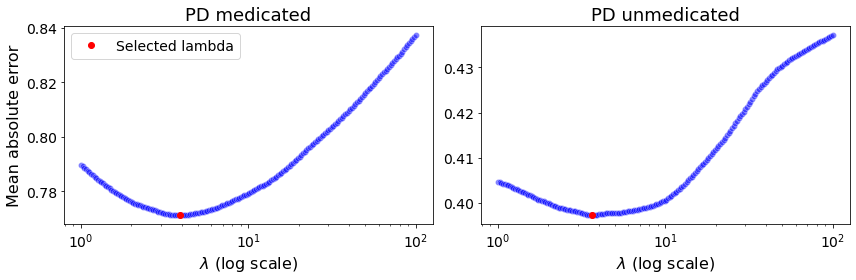

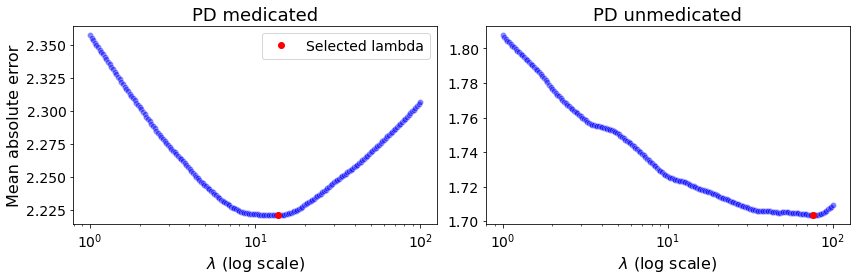

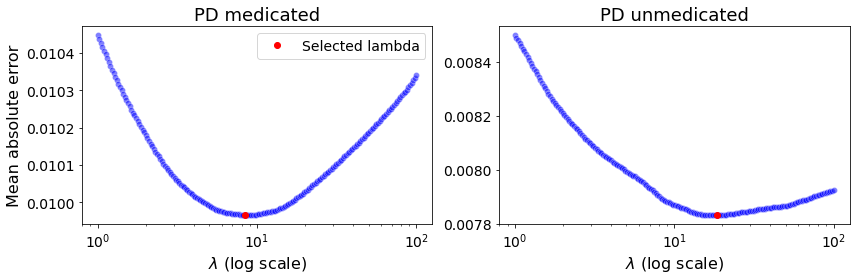

In [ ]:
for measure in measures: 
    df_measure = l1tf_values[population]['measure'][measure]
    df_signal = l1tf_values[population]['signal'][measure]
    df_error = l1tf_values[population]['error'][measure]
    df_snr_lambda = l1tf_values[population]['snr_lambda'][measure]

    med_idx = [0, len(pd_med_ids) - 1]
    no_med_idx = [len(pd_med_ids), len(pd_med_ids) + len(pd_no_med_ids) - 1]

    df_residual = df_measure - df_signal

    std_signal = df_signal.std(axis=1, ddof=1)
    std_residual = df_residual.std(axis=1, ddof=1)

    snr = std_signal / std_residual
    snr_median = np.nanmedian(snr)
    snr_iqr = [np.nanpercentile(snr, 25), np.nanpercentile(snr, 75)]

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True, sharey=False)

    lambdas = np.logspace(0, 2, 200)

    for j, med_status in enumerate(['med', 'no_med']):
        if med_status == 'med':
            med_status_idx = med_idx
        else:
            med_status_idx = no_med_idx

        df_error_med_state = df_error.iloc[med_status_idx[0]:med_status_idx[1] + 1]
        df_snr_lambda_med_state = df_snr_lambda.iloc[med_status_idx[0]:med_status_idx[1] + 1]

        df_error_plot = pd.DataFrame([lambdas, df_error_med_state.mean(axis=0)]).T
        df_error_plot.columns = ['lambda', 'error']
        sns.scatterplot(df_error_plot, x='lambda', y='error', color='blue', alpha=0.5, ax=ax[j])

        df_iqr_snr_lambda = df_snr_lambda_med_state.set_index('SubjectID').quantile([0.25, 0.5, 0.75]).T.reset_index(drop=True)
        df_iqr_snr_lambda.columns = ['Q1', 'Q2', 'Q3']
        df_iqr_snr_lambda['lambda'] = lambdas

        optimal_lambda = df_error_plot.loc[df_error_plot['error'] == df_error_plot['error'].min(), 'lambda'].values[0]
        optimal_idx = np.where(np.isclose(lambdas, optimal_lambda))[0][0]
        ax[j].plot(optimal_lambda, df_error_plot.loc[optimal_idx, 'error'], 'ro', label='Selected lambda')

        ax[j].set_xlabel(r'$\lambda$ (log scale)', size=PLOT_LABELSIZE)
        ax[j].set_xscale('log')
        ax[j].tick_params(labelsize=PLOT_TICKSIZE)

        ax[j].set_title(f'PD {GROUP_RENAMING[med_status].lower()}', size=PLOT_TITLESIZE)

    ax[0].legend(fontsize=PLOT_LEGEND_FONTSIZE)
    ax[0].set_ylabel('Mean absolute error', size=PLOT_LABELSIZE)
    ax[1].set_ylabel('')

            
    plt.tight_layout()
    plt.show()

# SNR for cohorts and markers

In [16]:
filter_type = 'unfiltered'
rounding_decimals = 3
suffix = ''  # ''  or '_interp

ids_df = pd_med_ids + pd_no_med_ids

for measure in measures:
    print(f"---- Measure: {measure} ----")
    for group in ['pd_med', 'pd_no_med', 'controls']:
        print(f"Group: {group}")

        if group == 'pd_med':
            df_measure = l1tf_values['pd']['measure'][measure].iloc[:len(pd_med_ids) - 1]
            df_signal = l1tf_values['pd']['signal'][measure].iloc[:len(pd_med_ids) - 1]
        elif group == 'pd_no_med':
            df_measure = l1tf_values['pd']['measure'][measure].iloc[len(pd_med_ids):]
            df_signal = l1tf_values['pd']['signal'][measure].iloc[len(pd_med_ids):]
        else:
            df_measure = l1tf_values['controls']['measure'][measure]
            df_signal = l1tf_values['controls']['signal'][measure]

        df_residual = df_measure - df_signal

        std_signal = df_signal.std(axis=1, ddof=1)
        std_residual = df_residual.std(axis=1, ddof=1)

        std_signal_iqr = [np.nanpercentile(std_signal, 25), np.nanpercentile(std_signal, 75)]
        std_noise_iqr = [np.nanpercentile(std_residual, 25), np.nanpercentile(std_residual, 75)]

        snr = std_signal / std_residual
        snr_median = np.nanmedian(snr)
        snr_iqr = [np.nanpercentile(snr, 25), np.nanpercentile(snr, 75)]

        print(f"std signal = {np.round(np.nanmedian(std_signal), rounding_decimals)} [{np.round(std_signal_iqr[0], rounding_decimals)}, {np.round(std_signal_iqr[1], rounding_decimals)}]")
        print(f"std noise = {np.round(np.nanmedian(std_residual), rounding_decimals)} [{np.round(std_noise_iqr[0], rounding_decimals)}, {np.round(std_noise_iqr[1], rounding_decimals)}]")
        print(F"SNR = {np.round(snr_median, rounding_decimals)} [{np.round(snr_iqr[0], rounding_decimals)}, {np.round(snr_iqr[1], rounding_decimals)}]\n")


---- Measure: median ----
Group: pd_med
std signal = 0.78 [0.422, 1.327]
std noise = 0.858 [0.575, 1.26]
SNR = 0.88 [0.602, 1.28]

Group: pd_no_med
std signal = 0.405 [0.215, 0.995]
std noise = 0.557 [0.386, 0.863]
SNR = 0.763 [0.485, 1.162]

Group: controls
std signal = 0.566 [0.329, 1.003]
std noise = 0.894 [0.622, 1.128]
SNR = 0.664 [0.426, 1.17]

---- Measure: 95p ----
Group: pd_med
std signal = 2.137 [1.317, 3.398]
std noise = 2.463 [1.771, 3.534]
SNR = 0.827 [0.583, 1.249]

Group: pd_no_med
std signal = 1.701 [0.861, 2.668]
std noise = 2.337 [1.559, 3.344]
SNR = 0.639 [0.393, 0.926]

Group: controls
std signal = 1.104 [0.536, 2.001]
std noise = 2.178 [1.575, 2.581]
SNR = 0.502 [0.231, 0.95]

---- Measure: median_cov ----
Group: pd_med
std signal = 0.008 [0.005, 0.013]
std noise = 0.013 [0.01, 0.015]
SNR = 0.606 [0.383, 0.99]

Group: pd_no_med
std signal = 0.008 [0.005, 0.012]
std noise = 0.014 [0.011, 0.018]
SNR = 0.506 [0.308, 0.839]

Group: controls
std signal = 0.003 [0.002, 0

# Store the interpolated signal for SRM analysis

In [17]:
for group in ['pd', 'controls']:
    for measure in measures:
        measure_extended = f'{measure}_range_of_motion'
        l1tf_values[group]['signal_interp'][measure].to_csv(os.path.join(path_l1tf, f'{group}_signal_interp_{measure_extended}.csv'), index=False)
        for week in final_week_range:
            l1tf_phased[measure][week].to_csv(os.path.join(path_l1tf, 'lambda_fit_by_duration', f'{group}_signal_interp_{measure_extended}_upto_{week}w.csv'), index=False)

# Plot examples

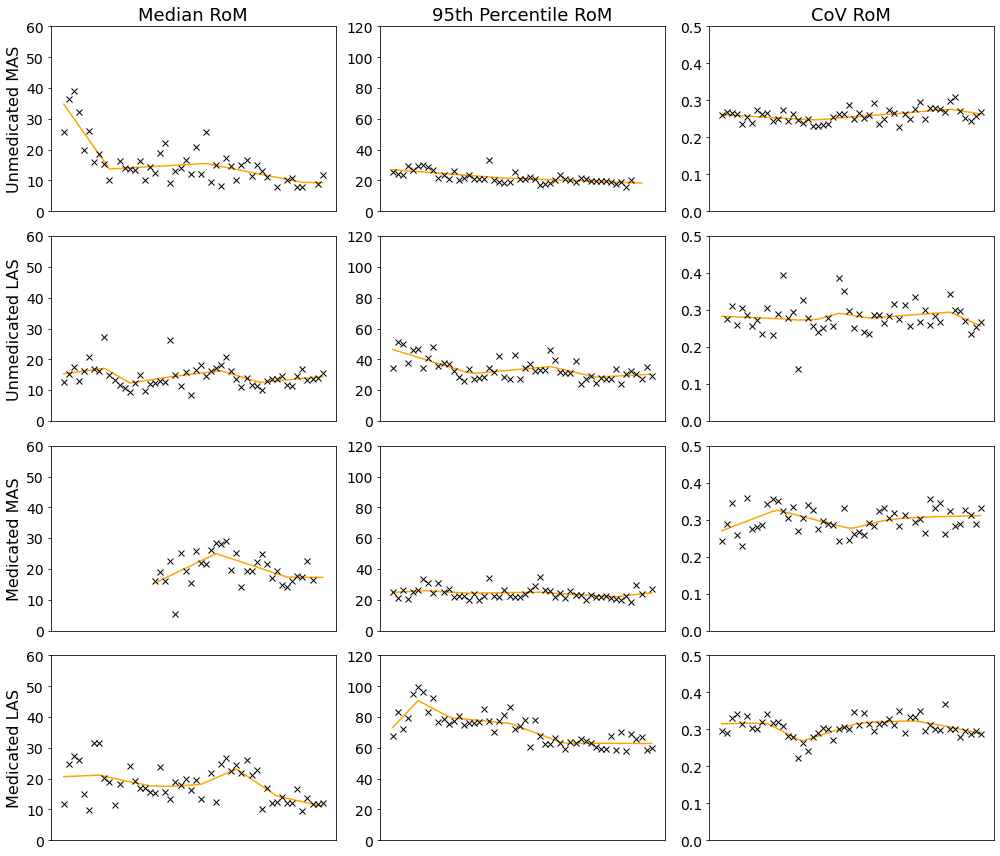

In [ ]:
group = 'pd'

plot_labels = {
    'median': 'Median RoM',
    '95p': '95th Percentile RoM',
    'median_cov': 'CoV RoM'
}

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(14, 12), sharex=True, sharey=False)

for j, measure in enumerate(measures):
    for i, med_state in enumerate(['no_med', 'med']):
        for k, affected_side in enumerate(['mas', 'las']):
            subject_ids = affected_side_ids['ppp'][affected_side] + affected_side_ids['denovo'][affected_side]
            if med_state == 'med':
                subject_idx = [pd_med_ids.index(i) for i in subject_ids if i in pd_med_ids and pd_med_ids.index(i) < len(l1tf_values[group]['signal_interp'][measure])]
            else:
                subject_idx = [len(pd_med_ids) + pd_no_med_ids.index(i) for i in subject_ids if i in pd_no_med_ids and len(pd_med_ids) + pd_no_med_ids.index(i) < len(l1tf_values[group]['signal_interp'][measure])]

            subject_idx_valid = [idx for idx in subject_idx if pd.notna(l1tf_values[group]['signal_interp'][measure].loc[idx, 'week100'])]

            r_subject = np.random.choice(subject_idx_valid)

            df_signal = l1tf_values[group]['signal_interp'][measure].iloc[r_subject]
            df_measure = l1tf_values[group]['measure'][measure].iloc[r_subject]

            ax[k + 2 * i, j].plot(df_signal, label=f'{med_state.upper()} {affected_side.upper()} - Subject {j + 1}', linestyle='-', color='orange')
            ax[k + 2 * i, j].plot(df_measure, label=f'{med_state.upper()} {affected_side.upper()} - Subject {j + 1} (Measurement)', marker='x', linestyle='None', color='black')
            ax[k + 2 * i, j].set_ylabel('')
            ax[k + 2 * i, j].set_xticks([])
            ax[k + 2 * i, j].set_xticklabels([])

            if measure == 'median':
                ax[i + 2 * k, j].set_ylim([0, 60])
            elif measure == '95p':
                ax[i + 2 * k, j].set_ylim([0, 120])
            else:
                ax[i + 2 * k, j].set_ylim([0, 0.5])
            ax[k + 2 * i, j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)

    ax[0, j].set_title(plot_labels[measure], size=PLOT_TITLESIZE)

ax[0, 0].set_ylabel('Unmedicated MAS', fontsize=PLOT_LABELSIZE)
ax[1, 0].set_ylabel('Unmedicated LAS', fontsize=PLOT_LABELSIZE)
ax[2, 0].set_ylabel('Medicated MAS', fontsize=PLOT_LABELSIZE)
ax[3, 0].set_ylabel('Medicated LAS', fontsize=PLOT_LABELSIZE)

plt.tight_layout()
plt.show()